# Bike Sharing Demand Forecasting

*Joshua Ren 3041881898*

*May 07, 2026*

---


In [1]:
from data import load_raw_hourly, data_overview
from eda import (
    basic_summary,
    log_dependence_data,
    plot_acf_pacf_diagnostics,
    plot_calendar_patterns,
    plot_demand_scale,
    plot_mean_variance_check,
    plot_weather_relationships,
    plot_welch_periodograms,
    set_analysis_style,
)
from preprocessing import prepare_hourly_data, chronological_split, split_summary

set_analysis_style()


---

## 1. Data Loading and Preprocessing

This project uses the hourly file from the Bike Sharing Dataset on Kaggle. The data cover Capital Bikeshare rentals in Washington, DC from January 1, 2011 through December 31, 2012. Each row records the total number of rentals in one hour, together with calendar and weather information. The response variable is `cnt`, the aggregate hourly rental count.

**Variables in `hour.csv`**

| Group | Variable | Type | Description | Values / units |
|---|---|---|---|---|
| Time and calendar | `instant` | int | Record index in the original file | 1-17,379 |
| Time and calendar | `dteday` | date | Calendar date of the observation | YYYY-MM-DD |
| Time and calendar | `season` | int | Season indicator | 1: spring, 2: summer, 3: fall, 4: winter |
| Time and calendar | `yr` | int | Year indicator | 0: 2011, 1: 2012 |
| Time and calendar | `mnth` | int | Month of year | 1-12 |
| Time and calendar | `hr` | int | Hour of day | 0-23 |
| Time and calendar | `holiday` | int | Holiday indicator | 1: yes, 0: no |
| Time and calendar | `weekday` | int | Day of week | 0-6 |
| Time and calendar | `workingday` | int | Working-day indicator | 1: yes, 0: no |
| Weather | `weathersit` | int | Weather condition | 1: clear, 2: mist/cloudy, 3: light snow/rain, 4: heavy rain/snow |
| Weather | `temp` | float | Normalized temperature | scaled to [0, 1] |
| Weather | `atemp` | float | Normalized feeling temperature | scaled to [0, 1] |
| Weather | `hum` | float | Normalized humidity | scaled to [0, 1] |
| Weather | `windspeed` | float | Normalized wind speed | scaled to [0, 1] |
| Demand | `casual` | int | Count of non-registered users | hourly rental count |
| Demand | `registered` | int | Count of registered users | hourly rental count |
| Demand | `cnt` | int | Total bike rental demand | hourly rental count |

`cnt` is used as the response variable. `casual` and `registered` are not used as predictors because they add up to `cnt`.

### 1.1 Raw Data Overview

The first step loads `hour.csv`, creates an hourly timestamp, and checks the basic information of the raw data.

In [2]:
raw_df = load_raw_hourly()
data_overview(raw_df)

rows                                  17379
start_timestamp         2011-01-01 00:00:00
end_timestamp           2012-12-31 23:00:00
duplicate_timestamps                      0
expected_hours                        17544
observed_hours                        17379
missing_hours                           165
dtype: object

The file contains 17,379 hourly records. There are no duplicate timestamps, but the full hourly range should contain 17,544 hours, so 165 timestamps are missing and need to be handled before modeling.

### 1.2 Preprocess Hourly Data

The preprocessing step turns the raw file into a complete hourly series for modeling. It

- Reindex to the full hourly range so missing timestamps become rows.
- Extract calendar fields from the timestamp.
- Interpolate continuous variables.
- Keep only variables used later in the analysis.

In [3]:
model_df = prepare_hourly_data(raw_df)
model_df.head()

,cnt,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,hum,windspeed
timestamp,,,,,,,,,,,,
2011-01-01 00:00:00,16.0,1,0,1,0,0,6,0,1.0,0.24,0.81,0.0
2011-01-01 01:00:00,40.0,1,0,1,1,0,6,0,1.0,0.22,0.80,0.0
2011-01-01 02:00:00,32.0,1,0,1,2,0,6,0,1.0,0.22,0.80,0.0
2011-01-01 03:00:00,13.0,1,0,1,3,0,6,0,1.0,0.24,0.75,0.0
2011-01-01 04:00:00,1.0,1,0,1,4,0,6,0,1.0,0.24,0.75,0.0


---

## 2. Exploratory Data Analysis

This section looks for structure in hourly demand that matters for forecasting.

### 2.1 Basic Summary

I first check the prepared modeling frame. Before looking for patterns, the data should have complete values and reasonable ranges after preprocessing.

In [4]:
basic_summary(model_df)

,count,missing,mean,std,min,25%,50%,75%,max
cnt,17544,0,187.886485,181.278201,1.00,38.0000,140.000,279.0000,977.0000
season,17544,0,2.507524,1.117429,1.00,2.0000,3.000,4.0000,4.0000
yr,17544,0,0.500684,0.500014,0.00,0.0000,1.000,1.0000,1.0000
mnth,17544,0,6.519836,3.449649,1.00,4.0000,7.000,10.0000,12.0000
hr,17544,0,11.500000,6.922384,0.00,5.7500,11.500,17.2500,23.0000
holiday,17544,0,0.028728,0.167045,0.00,0.0000,0.000,0.0000,1.0000
weekday,17544,0,2.997264,2.003472,0.00,1.0000,3.000,5.0000,6.0000
workingday,17544,0,0.683995,0.464928,0.00,0.0000,1.000,1.0000,1.0000
weathersit,17544,0,1.434223,0.648339,1.00,1.0000,1.000,2.0000,4.0000
temp,17544,0,0.495044,0.193192,0.02,0.3400,0.500,0.6600,1.0000


The prepared data are complete after preprocessing. The response is nonnegative and right-skewed, which is expected for hourly demand.

### 2.2 Demand Scale and Overall Time Pattern

After checking completeness, I look at the target scale and its movement over time.

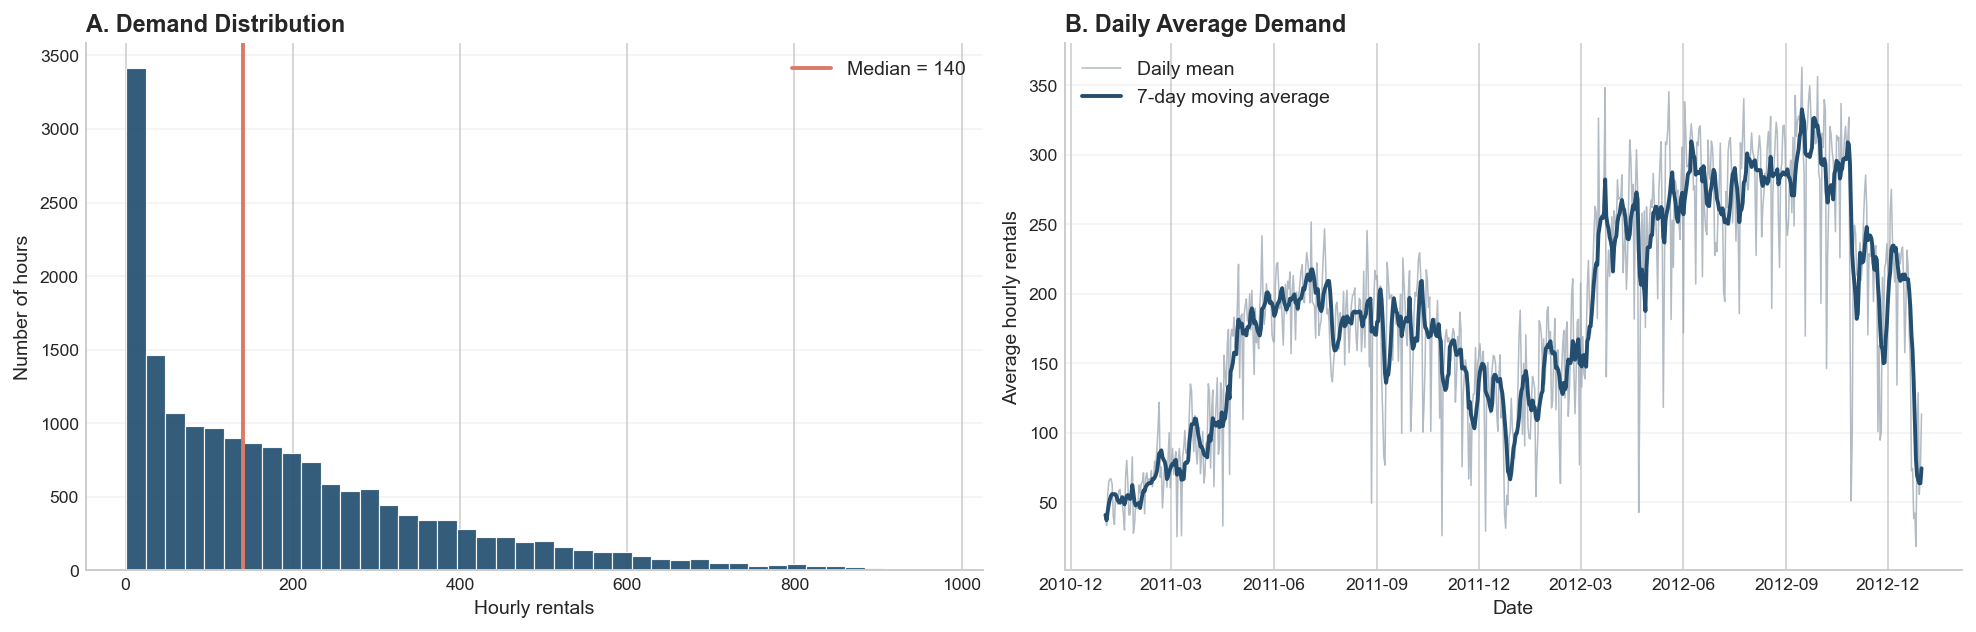

In [5]:
plot_demand_scale(model_df)


Most hours have low to moderate demand, while a smaller number of peak hours form a long upper tail. Daily average demand also shows clear seasonal pattern over the two years.

### 2.3 Calendar Patterns

The next question is whether demand changes systematically with the calendar. I summarize monthly, weekly, and hourly patterns in this section.

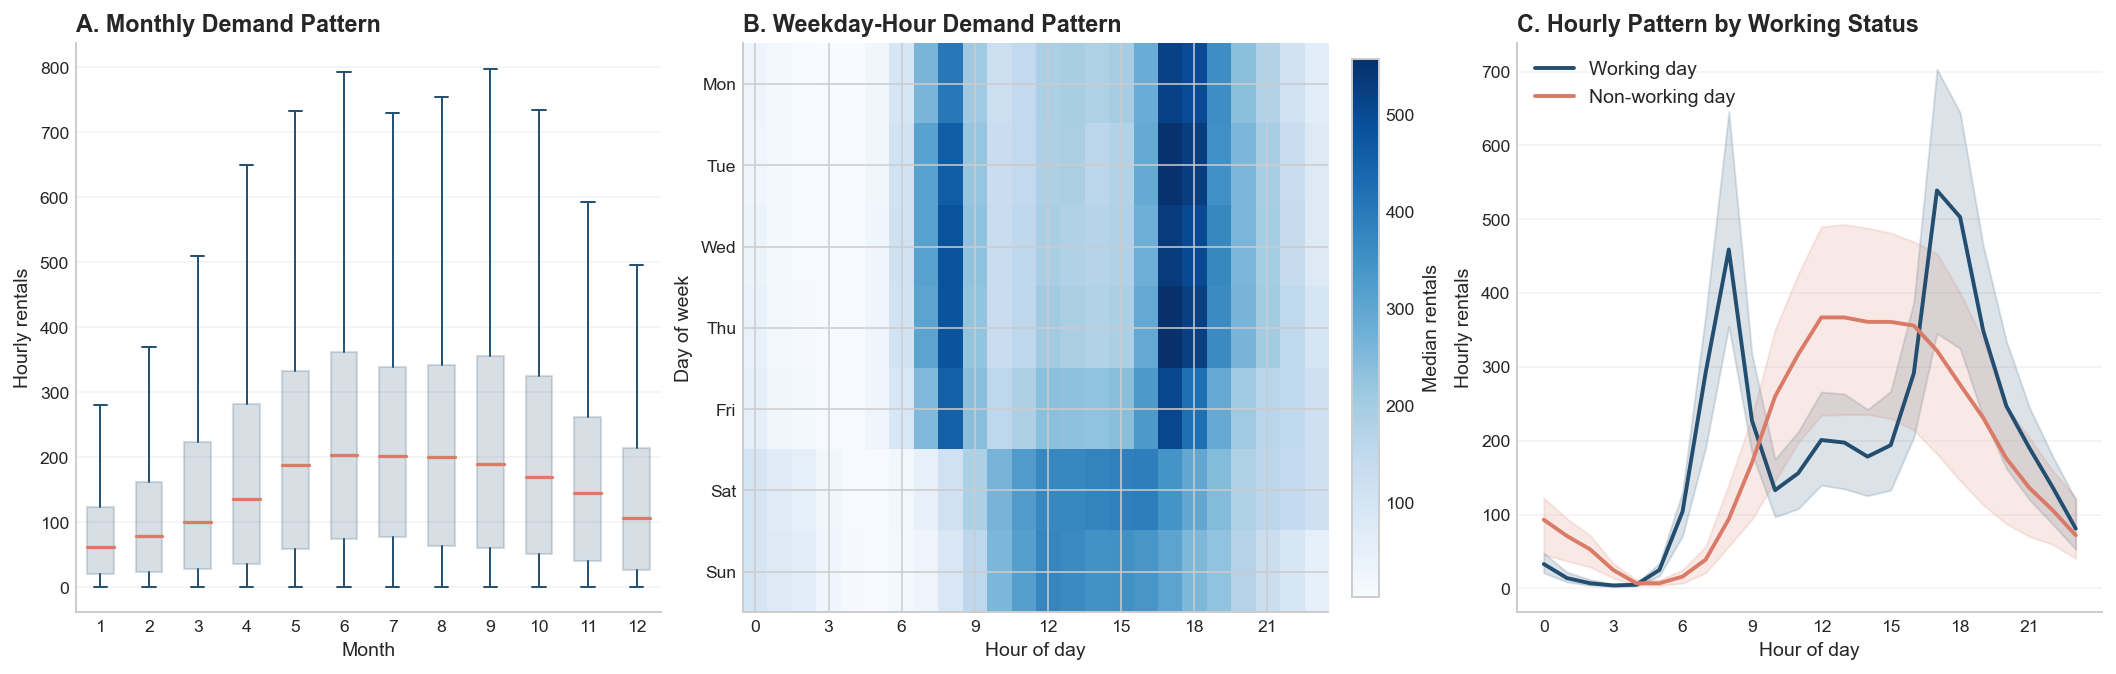

In [6]:
plot_calendar_patterns(model_df)


Demand is higher in warmer months and has a clear weekday-hour pattern. Working days show commute peaks, while non-working days shift demand toward the middle of the day. These patterns support using month, hour, weekday, working-day status, and seasonal lag features.

### 2.4 Weather Relationships

Weather is a second source of structure. I check whether demand changes with temperature, humidity, wind speed, and weather condition.

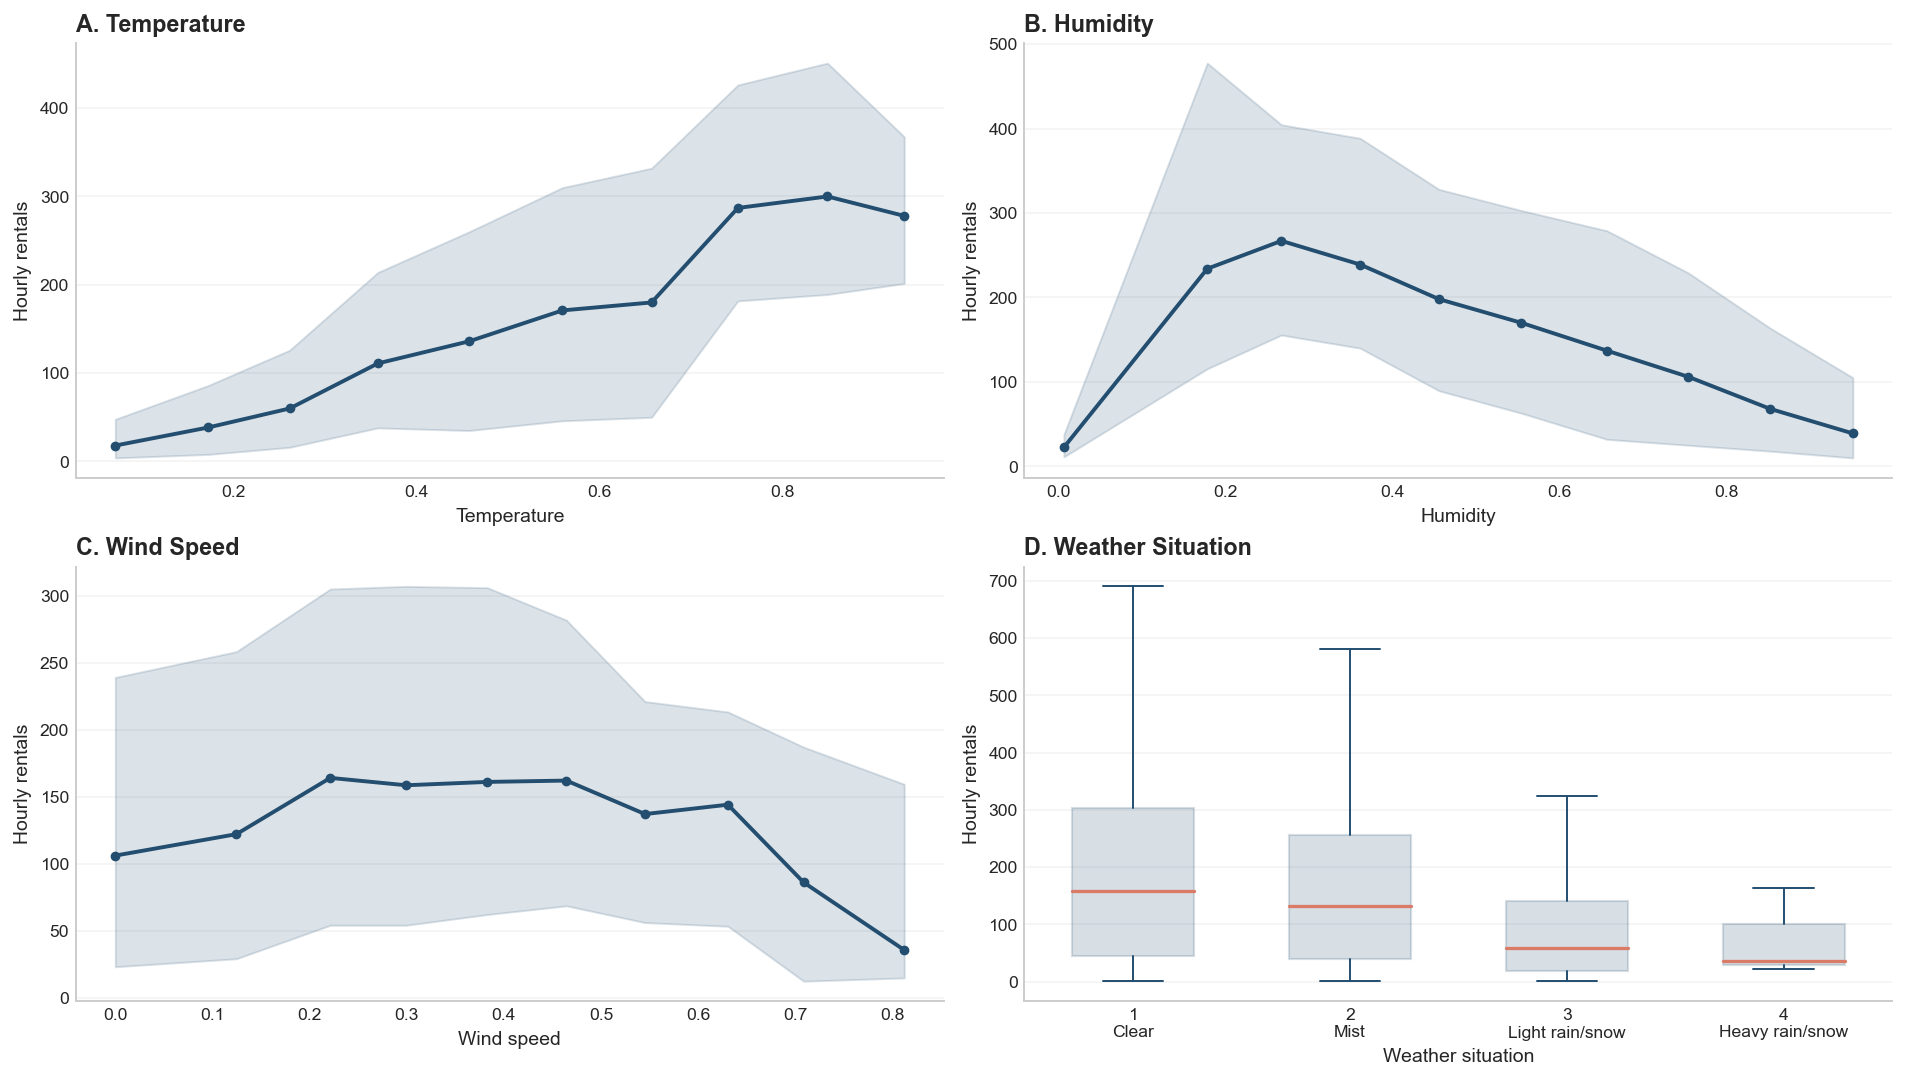

In [7]:
plot_weather_relationships(model_df)


Demand generally rises with temperature and falls when humidity is high. Wind speed is weaker and noisier, while worse weather conditions clearly reduce demand. Therefore, weather variables may also need to be taken into consideration in the models.

### 2.5 Mean-Variance Relationship

Before moving to serial dependence, I check the mean-variance relationship. If high-demand periods also have much higher variance, a log transform may be needed to stablize variance.

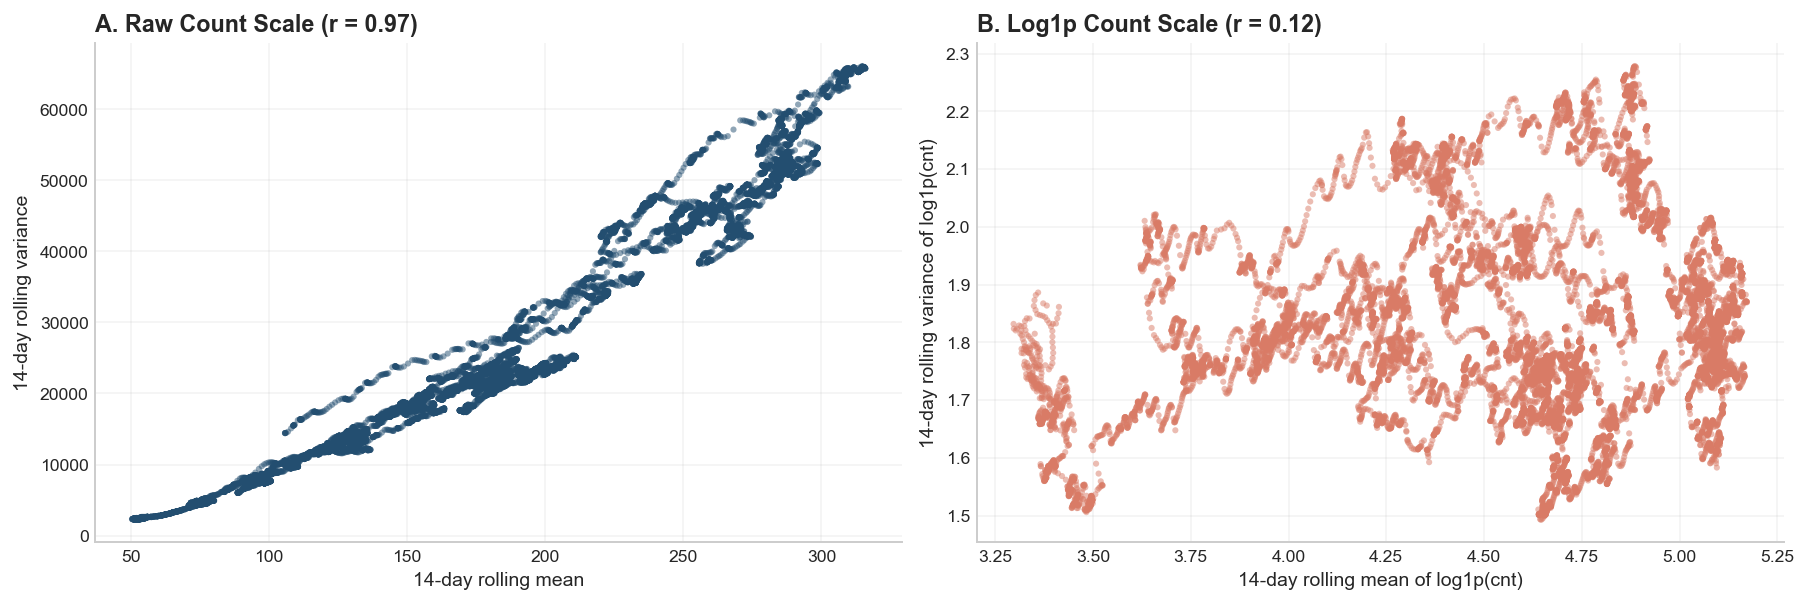

In [8]:
plot_mean_variance_check(model_df)


The raw count scale has a strong mean-variance relationship. And the `log1p` scale weakens it sharply, so I use `log1p(cnt)` in later analysis.

### 2.6 Autocorrelation and Differencing

The calendar plots suggest strong repeating patterns. Here I check whether those patterns also show up in the series itself. I compare the log series, first difference, and 24-hour difference to see which lagged signals are important.

In [9]:
acf_summary, log_cnt, log_diff_1, log_diff_24 = log_dependence_data(model_df)
acf_summary.round(3)


,log_cnt,log_diff_1,log_diff_24
lag_1,0.900,0.493,0.757
lag_2,0.700,0.185,0.494
lag_3,0.464,-0.091,0.211
lag_24,0.866,0.677,-0.175
lag_48,0.779,0.535,-0.231
lag_168,0.909,0.774,0.438


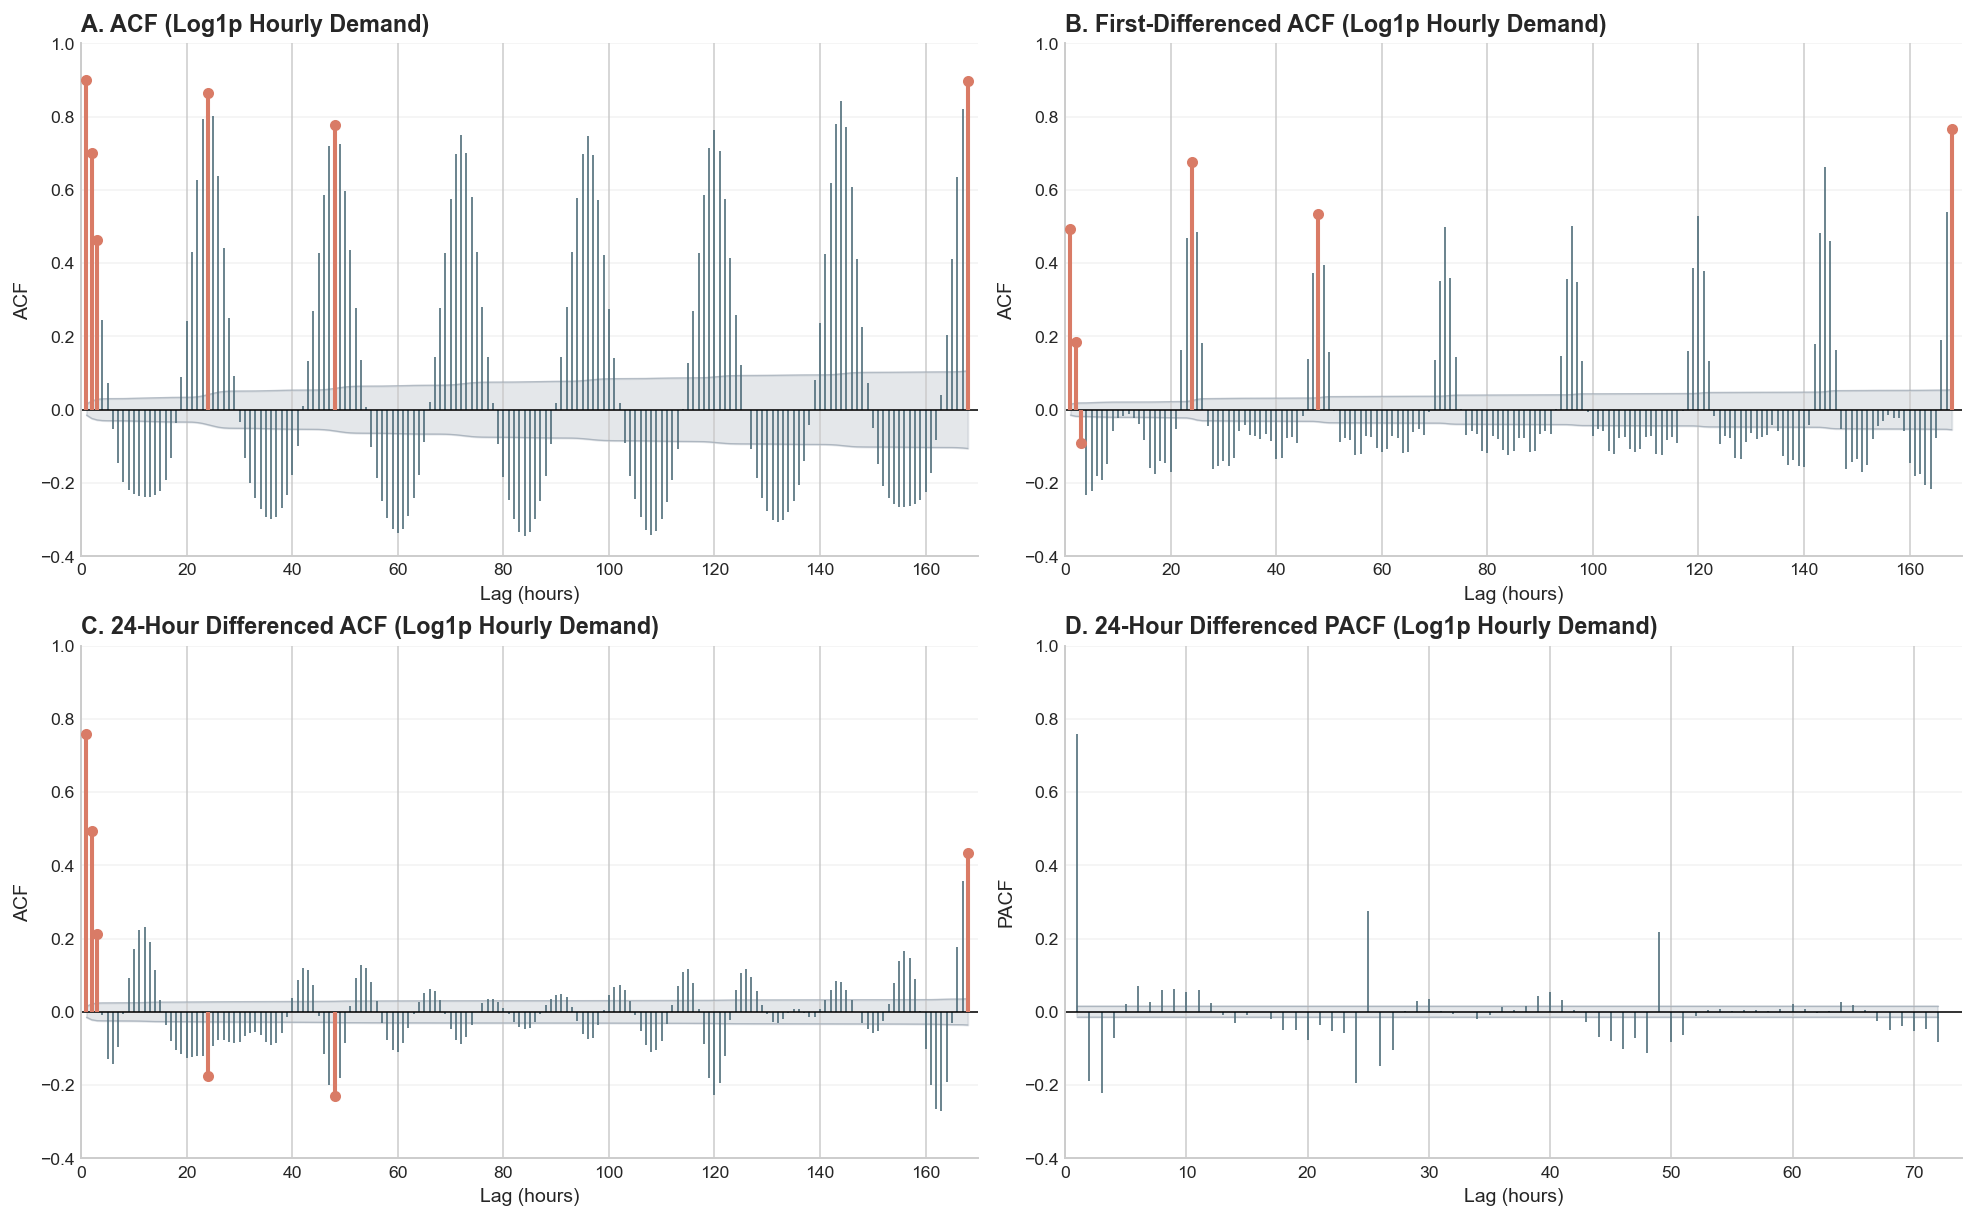

In [10]:
plot_acf_pacf_diagnostics(log_cnt, log_diff_1, log_diff_24)


On the log scale, the series is still very persistent. The ACF is about 0.90 at lag 1, and the daily and weekly lags are also large. Lag 24 is about 0.87, lag 48 is about 0.78, and lag 168 is about 0.91. This is the same daily and weekly structure from the calendar plots.

First differencing lowers the local persistence. Lag 1 drops to about 0.49. However, lag 24 and lag 168 are still high, around 0.68 and 0.77. So ordinary differencing does not remove the repeated daily and weekly pattern.

The 24-hour difference is more aligned with this data because it compares each hour with the same hour yesterday. After this difference, the daily lags become much weaker, but the weekly structure still needs to be represented.

The PACF of the 24-hour differenced series still has short-lag spikes in the first few hours. This suggests that recent demand adds information even after the daily pattern is removed.

The ACF and PACF are time domain checks. I also use Welch's method to check the frequency domain.

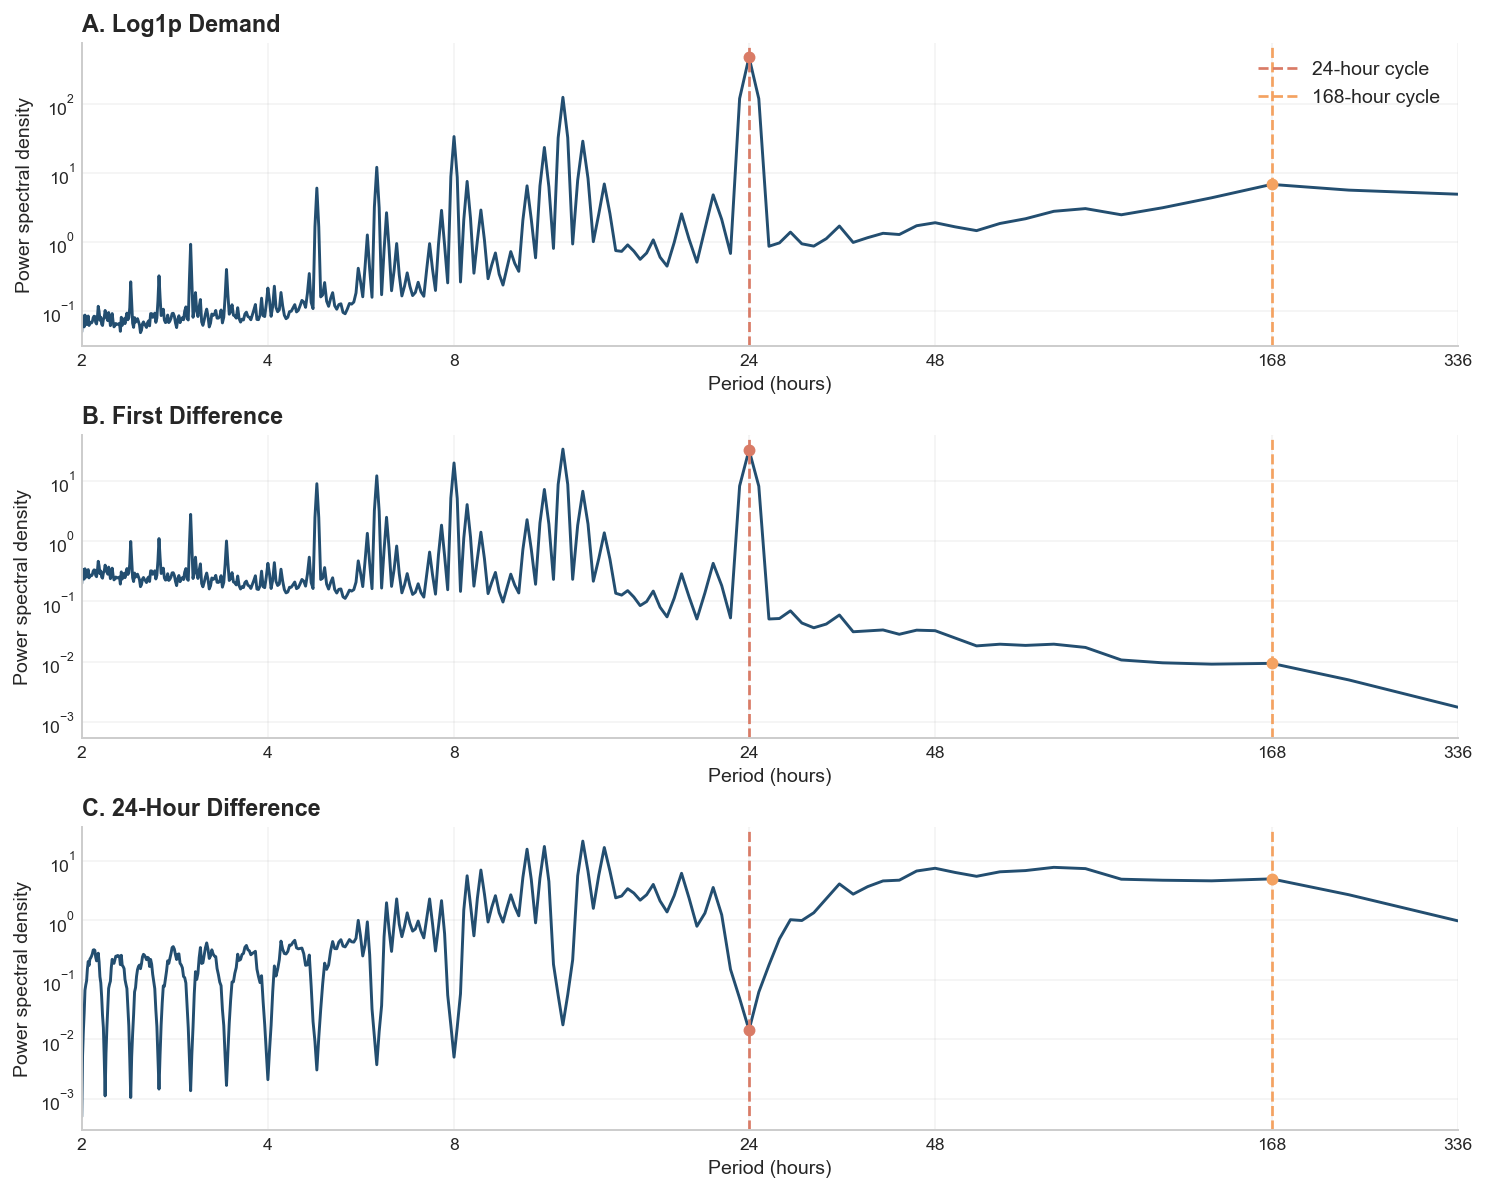

In [11]:
plot_welch_periodograms(log_cnt, log_diff_1, log_diff_24)


The frequency plots tell the same story from a different angle. In `log1p(cnt)`, power is concentrated near 24 hours. This means the daily cycle dominates the target series. After first differencing, the 24-hour peak is still visible, which agrees with the ACF result above.

After 24-hour differencing, power around 24 hours drops, and the 168-hour cycle becomes easier to see. This means the daily cycle has been partly removed, while the weekly cycle remains.

Here I do not make more difference to avoid introducing more MA structure.

## 3. Models

This section will compare the ARIMA benchmark, lagged regression, LSTM, RNN, and optional ARIMAX extension. Because the EDA motivates `log1p(cnt)` as the modeling scale, models that predict the target directly will be trained on the log-transformed response. Predictions will be transformed back with `expm1` before computing RMSE and MAE.

In [12]:
train_df, valid_df, test_df = chronological_split(model_df)
split_summary(train_df, valid_df, test_df)

,rows,start,end
train,10526,2011-01-01 00:00:00,2012-03-14 13:00:00
validation,3509,2012-03-14 14:00:00,2012-08-07 18:00:00
test,3509,2012-08-07 19:00:00,2012-12-31 23:00:00


## 4. Diagnostics and Interpretation

Add residual diagnostics, stationarity checks, the final comparison table, and the short interpretation that connects back to the project question.